   Training_Load  Sleep_Hours  Heart_Rate  Muscle_Soreness  Stress_Level  \
0           39.9          6.0       152.0                3             4   
1           46.7          8.3       156.0                3             1   
2           94.1          7.6       166.0                3             2   
3           35.2          7.0       169.0                3             3   
4           72.1          5.2       169.0                3             4   

  Recovery_Status  
0       Recovered  
1       Recovered  
2       Recovered  
3       Recovered  
4       Recovered  

Accuracy Results:
Logistic Regression: 0.9944444444444445
Decision Tree: 1.0
Random Forest: 1.0


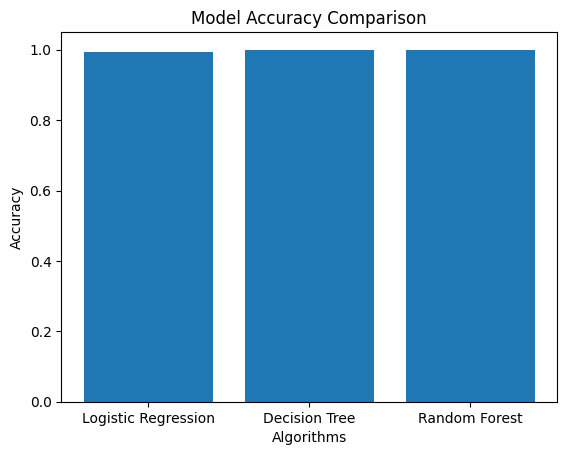

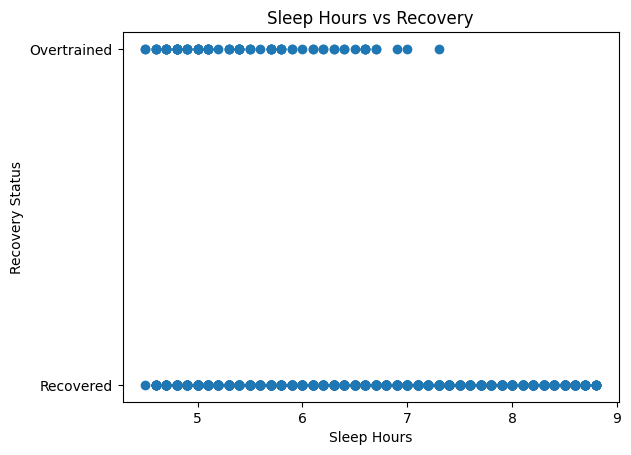

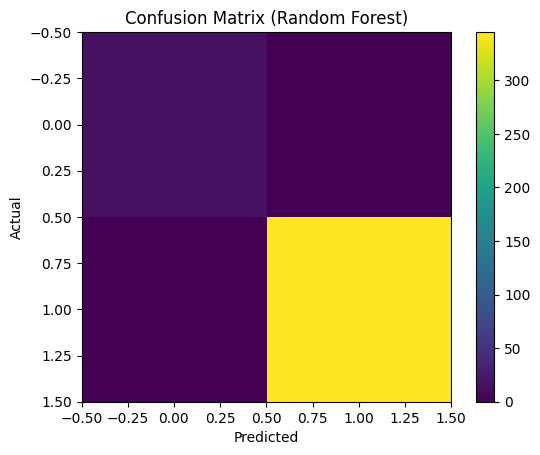

In [2]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Step 1: Load Dataset (IMPORTANT)
df = pd.read_csv("Muscle_Recovery_Final_Dataset.csv")

print(df.head())

# Step 2: Separate Features and Target
X = df.drop("Recovery_Status", axis=1)
y = df["Recovery_Status"]

# Step 3: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Step 4: Train Models
lr = LogisticRegression()
dt = DecisionTreeClassifier()
rf = RandomForestClassifier()

lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

# Step 5: Predictions
lr_pred = lr.predict(X_test)
dt_pred = dt.predict(X_test)
rf_pred = rf.predict(X_test)

# Step 6: Accuracy
lr_acc = accuracy_score(y_test, lr_pred)
dt_acc = accuracy_score(y_test, dt_pred)
rf_acc = accuracy_score(y_test, rf_pred)

print("\nAccuracy Results:")
print("Logistic Regression:", lr_acc)
print("Decision Tree:", dt_acc)
print("Random Forest:", rf_acc)

# -----------------------------
# 📊 GRAPH 1: Accuracy Comparison
# -----------------------------
models = ["Logistic Regression", "Decision Tree", "Random Forest"]
accuracies = [lr_acc, dt_acc, rf_acc]

plt.figure()
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.xlabel("Algorithms")
plt.ylabel("Accuracy")
plt.show()

# -----------------------------
# 📊 GRAPH 2: Sleep vs Recovery
# -----------------------------
plt.figure()
plt.scatter(df["Sleep_Hours"], df["Recovery_Status"])
plt.title("Sleep Hours vs Recovery")
plt.xlabel("Sleep Hours")
plt.ylabel("Recovery Status")
plt.show()

# -----------------------------
# 📊 GRAPH 3: Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_test, rf_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix (Random Forest)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()